## Imports e Configurações

In [ ]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")  
sns.set_context("talk")  

## Dataset

Os dados abaixo simulam **1000 leituras** do sistema de telemetria da nave Aurora Siger, cobrindo os parâmetros definidos no protocolo de pré-decolagem.

| Parâmetro | Faixa Segura |
|---|---|
| Temperatura interna | 15 – 30 °C |
| Temperatura externa | -20 – 40 °C |
| Integridade estrutural | 1 |
| Nível de energia | ≥ 80% |
| Pressão dos tanques | 3 – 5 bar |
| Módulo de Navegação | 1 |
| Módulo de Comunicação | 1 |
| Módulo de Propulsão | 1 |

In [53]:
N = 10000  
discrepancia_range = [0.10, 0.20]  

faixas = {
    'temp_interna'    : (15, 30),
    'temp_externa'    : (-20, 40),
    'energia_pct'     : (80, 100),
    'pressao_bar'     : (3.0, 5.0)
}

modulos = ['integridade', 'mod_navegacao', 'mod_comunicacao', 'mod_propulsao']

def gerar_valores(min_val, max_val, N, discrepancia):
    n_ok = int(N * (1 - discrepancia))
    n_bad = N - n_ok
    ok = np.random.uniform(min_val, max_val, n_ok)
    bad_baixo = np.random.uniform(min_val - (max_val - min_val), min_val - 0.1, n_bad//2)
    bad_alto  = np.random.uniform(max_val + 0.1, max_val + (max_val - min_val), n_bad - n_bad//2)
    return np.concatenate([ok, bad_baixo, bad_alto])

df = pd.DataFrame({'leitura_id': range(1, N+1)})

for param, (min_val, max_val) in faixas.items():
    disc = np.random.uniform(*discrepancia_range)
    df[param] = gerar_valores(min_val, max_val, N, disc).round(2)

for param in modulos:
    disc = np.random.uniform(*discrepancia_range)
    df[param] = np.random.choice([1, 0], size=N, p=[1-disc, disc])
df = df.sample(frac=1).reset_index(drop=True)

df.head(10)

,leitura_id,temp_interna,temp_externa,energia_pct,pressao_bar,integridade,mod_navegacao,mod_comunicacao,mod_propulsao
0,5738,26.37,36.60,87.07,3.18,1,1,0,1
1,9379,39.74,73.10,104.73,5.47,0,1,1,1
2,7684,29.60,-2.36,92.11,4.61,1,1,1,0
3,5475,24.29,0.45,95.65,4.34,1,0,1,1
4,9593,40.83,71.33,103.98,5.22,1,1,1,1
5,2624,25.20,-8.15,96.38,3.17,1,1,1,1
6,696,23.62,-5.00,92.14,3.26,1,1,1,1
7,5231,25.66,7.47,85.23,3.16,0,1,1,1
8,7570,16.10,2.38,97.47,4.68,1,1,1,1
9,1363,17.85,-5.49,81.76,4.01,1,1,1,1


## Verificações

In [54]:
temp_interna_ok    = (df['temp_interna'] >= 15.0) & (df['temp_interna'] <= 30.0)
temp_externa_ok    = (df['temp_externa'] >= -20.0) & (df['temp_externa'] <= 40.0)
integridade_ok     = df['integridade'] == 1
energia_ok         = df['energia_pct'] >= 80.0
pressao_ok         = (df['pressao_bar'] >= 3.0) & (df['pressao_bar'] <= 5.0)
mod_navegacao_ok   = df['mod_navegacao'] == 1
mod_comunicacao_ok = df['mod_comunicacao'] == 1
mod_propulsao_ok   = df['mod_propulsao'] == 1

sistemas_ok = (
    mod_navegacao_ok
    & mod_comunicacao_ok
    & mod_propulsao_ok
)

condicoes_ok = (
    temp_interna_ok
    & temp_externa_ok
    & integridade_ok
    & energia_ok
    & pressao_ok
)

df['status'] = 'DECOLAGEM ABORTADA'
df.loc[sistemas_ok & condicoes_ok, 'status'] = 'PRONTO PARA DECOLAR'

df.status.head()

0    DECOLAGEM ABORTADA
1    DECOLAGEM ABORTADA
2    DECOLAGEM ABORTADA
3    DECOLAGEM ABORTADA
4    DECOLAGEM ABORTADA
Name: status, dtype: object

## Tipos de falha

In [55]:
CHECKS = {
    'temp_interna'    : lambda v: 15.0 <= v <= 30.0,
    'temp_externa'    : lambda v: -20.0 <= v <= 40.0,
    'integridade'     : lambda v: v == 1,
    'energia_pct'     : lambda v: v >= 80.0,
    'pressao_bar'     : lambda v: 3.0 <= v <= 5.0,
    'mod_navegacao'   : lambda v: v == 1,
    'mod_comunicacao' : lambda v: v == 1,
    'mod_propulsao'   : lambda v: v == 1,
}

df['falhas'] = df.apply(
    lambda row: [p for p, fn in CHECKS.items() if not fn(row[p])],
    axis=1
)

df.loc[df['status'] == 'DECOLAGEM ABORTADA', ['leitura_id', 'status', 'falhas']].head(15)

,leitura_id,status,falhas
0,5738,DECOLAGEM ABORTADA,[mod_comunicacao]
1,9379,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, integridade, pres..."
2,7684,DECOLAGEM ABORTADA,[mod_propulsao]
3,5475,DECOLAGEM ABORTADA,[mod_navegacao]
4,9593,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, pressao_bar]"
7,5231,DECOLAGEM ABORTADA,[integridade]
11,9983,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, pressao_bar, mod_..."
12,9034,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, energia_pct, pres..."
14,5362,DECOLAGEM ABORTADA,[mod_propulsao]
15,9580,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, pressao_bar]"


## Visualizando

/tmp/ipykernel_3577/3031317777.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3577/3031317777.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


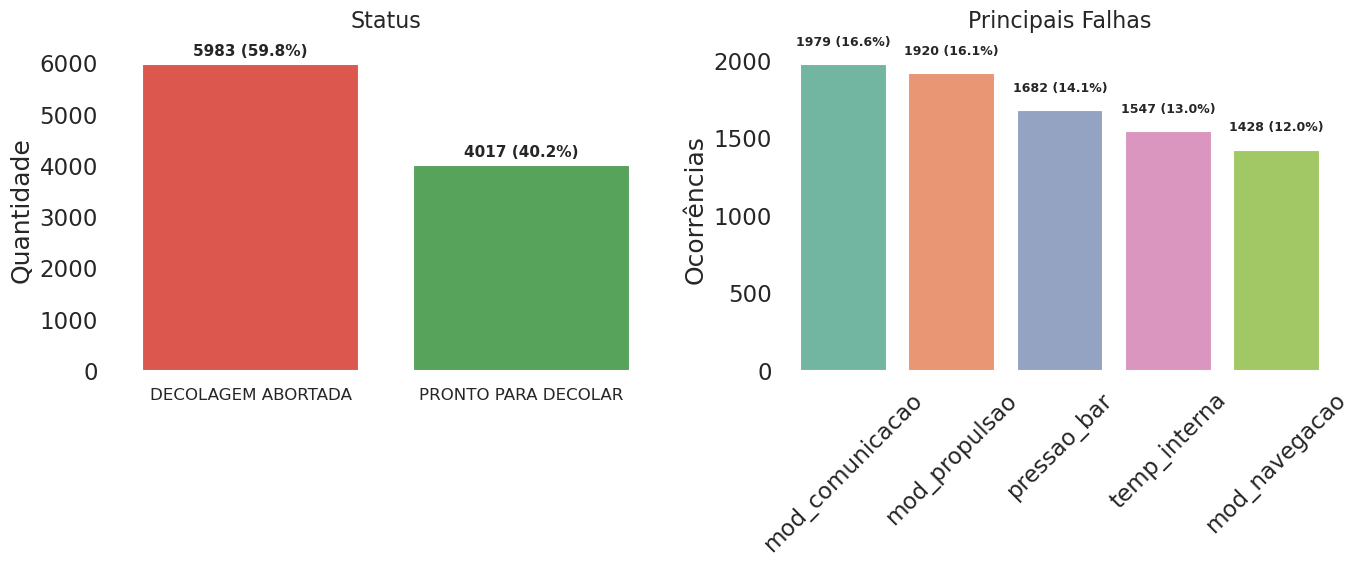

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
total = len(df)
status_counts = df['status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']
status_counts['pct'] = status_counts['count'] / status_counts['count'].sum() * 100

falhas_flat = [f for lista in df['falhas'] for f in lista]
falhas_counts = pd.Series(falhas_flat).value_counts().reset_index()
falhas_counts.columns = ['falha', 'count']
falhas_counts['pct'] = falhas_counts['count'] / falhas_counts['count'].sum() * 100
falhas_counts_top5 = falhas_counts.head(5)

status_colors = {'PRONTO PARA DECOLAR': '#4CAF50',  
                 'DECOLAGEM ABORTADA': '#F44336'}   
falhas_colors = sns.color_palette('Set2', n_colors=len(falhas_counts_top5))

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Status
sns.barplot(
    x='status', y='count', data=status_counts, ax=axes[0],
    palette=[status_colors[s] for s in status_counts['status']]
)
axes[0].set_title('Status', fontsize=16, pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', labelsize=12)
axes[0].grid(False)  
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)

# Valores e porcentagens sobre as barras
for i, row in status_counts.iterrows():
    axes[0].text(i, row['count'] + total*0.01, f"{row['count']} ({row['pct']:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Principais falhas
sns.barplot(
    x='falha', y='count', data=falhas_counts_top5, ax=axes[1],
    palette=falhas_colors
)
axes[1].set_title('Principais Falhas', fontsize=16, pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Ocorrências')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(False)  
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)

for i, row in falhas_counts_top5.iterrows():
    axes[1].text(i, row['count'] + total*0.01, f"{row['count']} ({row['pct']:.1f}%)",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Analise energetica

In [57]:
cap_total = 1500
carga_media = df['energia_pct'].mean()
consumo_decolagem = 700
perdas_pct = 8

energia_disponivel = cap_total * carga_media / 100
perdas = energia_disponivel * perdas_pct / 100
energia_real = energia_disponivel - perdas
margem = energia_real - consumo_decolagem
autonomia_ok = energia_real >= consumo_decolagem

energia_resultado = {
    'capacidade_total_kwh'  : cap_total,
    'carga_atual_pct'       : round(carga_media, 1),
    'energia_disponivel_kwh': round(energia_disponivel, 2),
    'perdas_kwh'            : round(perdas, 2),
    'energia_real_kwh'      : round(energia_real, 2),
    'consumo_decolagem_kwh' : consumo_decolagem,
    'margem_kwh'            : round(margem, 2),
    'autonomia_suficiente'  : autonomia_ok
}

print("Resultados da Análise de Energia:")
for key, value in energia_resultado.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

Resultados da Análise de Energia:
Capacidade Total Kwh: 1500
Carga Atual Pct: 90.1
Energia Disponivel Kwh: 1351.61
Perdas Kwh: 108.13
Energia Real Kwh: 1243.49
Consumo Decolagem Kwh: 700
Margem Kwh: 543.49
Autonomia Suficiente: True


## Analise feita por IA

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df[['temp_interna', 'temp_externa', 'energia_pct', 'pressao_bar',
        'mod_navegacao', 'mod_comunicacao', 'mod_propulsao', 'integridade']]
y = (df['status'] == 'PRONTO PARA DECOLAR').astype(int)

X_scaled = StandardScaler().fit_transform(X)

# C pequeno = regularização forte, evita coeficientes que explodem
model = LogisticRegression(C=0.01)
model.fit(X_scaled, y)

score = X_scaled @ model.coef_[0] + model.intercept_[0]
probs_pontos = 1 / (1 + np.exp(-score))

ordem  = np.argsort(score)
score  = score[ordem]
y_ord  = y.values[ordem]

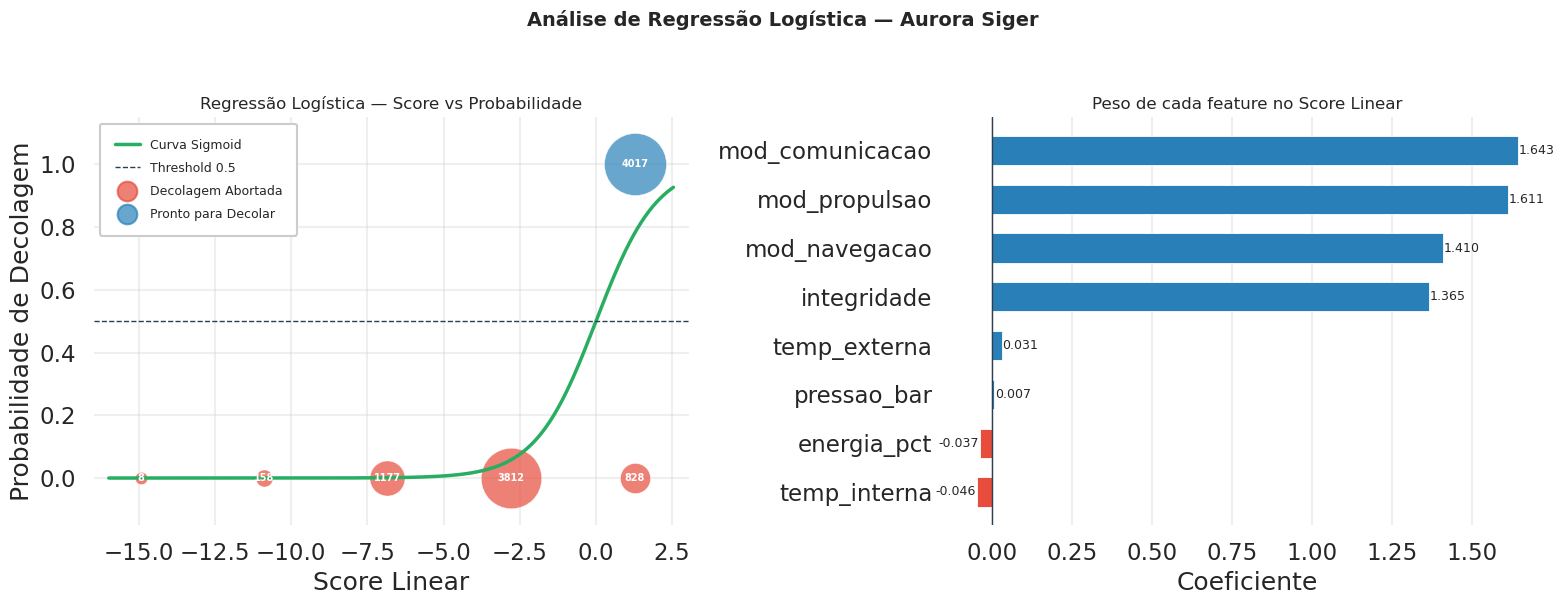

In [59]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Agrupa pontos próximos em "bolões" ---
def agrupar_pontos(scores, labels, tolerancia=0.8):
    pontos = sorted(zip(scores, labels), key=lambda x: x[0])
    grupos = []
    i = 0
    while i < len(pontos):
        grupo_scores = [pontos[i][0]]
        grupo_labels = [pontos[i][1]]
        j = i + 1
        while j < len(pontos) and pontos[j][0] - pontos[i][0] <= tolerancia:
            grupo_scores.append(pontos[j][0])
            grupo_labels.append(pontos[j][1])
            j += 1
        grupos.append((np.mean(grupo_scores), grupo_labels[0], len(grupo_scores)))
        i = j
    return grupos

grupos_0 = agrupar_pontos(score[y_ord == 0], y_ord[y_ord == 0])
grupos_1 = agrupar_pontos(score[y_ord == 1], y_ord[y_ord == 1])

# Escala do tamanho: mínimo visível, máximo razoável
todos_counts = [g[2] for g in grupos_0 + grupos_1]
min_c, max_c  = min(todos_counts), max(todos_counts)

def escalar_tamanho(n, min_n, max_n, min_s=80, max_s=2000):
    if max_n == min_n:
        return (min_s + max_s) / 2
    return min_s + (n - min_n) / (max_n - min_n) * (max_s - min_s)

for sx, label, count in grupos_0:
    s = escalar_tamanho(count, min_c, max_c)
    ax1.scatter(sx, 0, s=s, color='#e74c3c', alpha=0.7, edgecolors='white', linewidths=0.5)
    ax1.text(sx, 0, str(count), ha='center', va='center', fontsize=7, color='white', fontweight='bold')

for sx, label, count in grupos_1:
    s = escalar_tamanho(count, min_c, max_c)
    ax1.scatter(sx, 1, s=s, color='#2980b9', alpha=0.7, edgecolors='white', linewidths=0.5)
    ax1.text(sx, 1, str(count), ha='center', va='center', fontsize=7, color='white', fontweight='bold')

x_curva = np.linspace(score.min() - 1, score.max() + 1, 300)
y_curva = 1 / (1 + np.exp(-x_curva))

ax1.plot(x_curva, y_curva, color='#27ae60', linewidth=2.5, label='Curva Sigmoid')
ax1.axhline(0.5, color='#2c3e50', linestyle='--', linewidth=1, label='Threshold 0.5')
ax1.scatter([], [], s=200, color='#e74c3c', alpha=0.7, label='Decolagem Abortada')
ax1.scatter([], [], s=200, color='#2980b9', alpha=0.7, label='Pronto para Decolar')

ax1.set_title('Regressão Logística — Score vs Probabilidade', fontsize=12)
ax1.set_xlabel('Score Linear')
ax1.set_ylabel('Probabilidade de Decolagem')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(score.min() - 1.5, score.max() + 1.5)
ax1.set_ylim(-0.15, 1.15)

# --- Gráfico 2: Coeficientes ---
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
cores = ['#e74c3c' if v < 0 else '#2980b9' for v in coefs]

bars = ax2.barh(coefs.index, coefs.values, color=cores,
                edgecolor='white', linewidth=0.6, height=0.6)

for bar, val in zip(bars, coefs.values):
    ax2.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax2.axvline(0, color='#2c3e50', linewidth=1)
ax2.set_title('Peso de cada feature no Score Linear', fontsize=12)
ax2.set_xlabel('Coeficiente')
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('Análise de Regressão Logística — Aurora Siger', fontsize=14, fontweight='bold', y=1.02)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

ax1.legend(fontsize=9, frameon=True, framealpha=1, edgecolor='#cccccc',
           borderpad=1.2, labelspacing=0.8, handletextpad=0.8)

plt.tight_layout()
plt.show()